1) Importamos librerías

In [ ]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import wfdb
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [ ]:
# wfdb.dl_database("mitdb", dl_dir="mitbih_data")

2) Definimos funciones

In [ ]:

def load_mitbih_beats(record_id="100", window=200):

    record = wfdb.rdrecord(f"mitbih_data/{record_id}")
    annotation = wfdb.rdann(f"mitbih_data/{record_id}", "atr")

    signal = record.p_signal[:, 0]  # MLII

    X = []
    y = []

    for i, label in enumerate(annotation.symbol):

        if label not in ["N", "V"]:  # binario simple para empezar
            continue

        idx = annotation.sample[i]

        if idx - window < 0 or idx + window > len(signal):
            continue

        beat = signal[idx - window: idx + window]

        X.append(beat)
        y.append(0 if label == "N" else 1)

    return np.array(X), np.array(y)


def load_mitbih_all(records_id, window=200, classes=("N", "V")):
    """
    Loads all MIT-BIH records into a single dataset.

    Returns:
        X: (n_beats, 2*window)
        y: (n_beats,)
    """

    X_all = []
    y_all = []

    for rec in records_id:

        try:
            record = wfdb.rdrecord(f"mitbih_data/{rec}")
            ann = wfdb.rdann(f"mitbih_data/{rec}", "atr")

            signal = record.p_signal[:, 0]  # MLII

            for i, label in enumerate(ann.symbol):

                if label not in classes:
                    continue

                idx = ann.sample[i]

                if idx - window < 0 or idx + window >= len(signal):
                    continue

                beat = signal[idx - window: idx + window]

                X_all.append(beat)
                y_all.append(0 if label == classes[0] else 1)

        except Exception as e:
            print(f"Skipping record {rec}: {e}")

    return np.array(X_all), np.array(y_all)



def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(records_id, layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """

    if len(records_id) > 1:
        X_raw, y_raw = load_mitbih_all(records_id)
    elif len(records_id) == 1:
        X_raw, y_raw = load_mitbih_beats(record_id=records_id)

    X_pet = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)

def balance_dataset(X, y):

    idx_n = np.where(y == 0)[0]
    idx_v = np.where(y == 1)[0]

    idx_n = np.random.choice(idx_n, size=len(idx_v), replace=False)

    idx = np.concatenate([idx_n, idx_v])

    return X[idx], y[idx]

def experiment_ecg(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name="PET",
):
    """
    Evaluate several classifiers on a given feature representation.

    Parameters
    ----------
    X_train : ndarray
    X_test : ndarray
    y_train : ndarray
    y_test : ndarray
    feature_name : str
        Name of the representation (Raw, PET, Global PE...)

    Returns
    -------
    results_df : pd.DataFrame
        Table with all metrics.
    confusion_matrices : dict
        Confusion matrix for each classifier.
    """

    classifiers = {
        "1-NN Euclidean": KNeighborsClassifier(
            n_neighbors=1,
            metric="euclidean",
        ),
        "Linear SVM": SVC(
            kernel="linear",
            C=1.0,
        ),
        "RBF SVM": SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
        ),
    }

    results = []
    confusion_matrices = {}

    print(f"\n=== {feature_name} ===")

    for clf_name, clf in classifiers.items():

        clf.fit(X_train, y_train)

        preds = clf.predict(X_test)

        # Compute prediction scores for AUC
        if hasattr(clf, "predict_proba"):
            y_score = clf.predict_proba(X_test)
        else:
            y_score = clf.decision_function(X_test)

        acc = accuracy_score(y_test, preds)
        bal_acc = balanced_accuracy_score(y_test, preds)
        macro_f1 = f1_score(
            y_test,
            preds,
            average="macro",
        )

        # Compute AUC
        if len(np.unique(y_train)) == 2:
            # Binary classification
            if y_score.ndim == 2:
                auc = roc_auc_score(y_test, y_score[:, 1])
            else:
                auc = roc_auc_score(y_test, y_score)
            else:
                # Multiclass classification
                auc = roc_auc_score(
                    y_test,
                    y_score,
                    multi_class="ovr",
                    average="macro",
                    
                )

        cm = confusion_matrix(y_test, preds)

        confusion_matrices[clf_name] = cm

        results.append(
            {
                "Representation": feature_name,
                "Classifier": clf_name,
                "Feature dimension": X_train.shape[1],
                "Accuracy": acc,
                "Balanced accuracy": bal_acc,
                "Macro-F1": macro_f1,
                "AUC": auc,
            }
        )

        print(f"\n{clf_name}")
        print(f"Accuracy           : {acc:.4f}")
        print(f"Balanced accuracy  : {bal_acc:.4f}")
        print(f"Macro F1           : {macro_f1:.4f}")
        print(f"AUC                : {auc:.4f}")
        print("Confusion matrix:")
        print(cm)

        print("\nClassification report:")
        print(classification_report(y_test, preds))

    results_df = pd.DataFrame(results)

    return results_df, confusion_matrices

def plot_two_signals(X, y):
    """
    Plots one example per class from TwoLeadECG.
    """

    X = np.array(X)
    y = np.array(y)

    # find one sample per class
    idx_class_0 = np.where(y == 0)[0]
    idx_class_1 = np.where(y == 1)[0]

    sig0 = np.squeeze(X[idx_class_0])
    sig1 = np.squeeze(X[idx_class_1])

    t0 = np.arange(len(sig0))
    t1 = np.arange(len(sig1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(t0, sig0)
    plt.title("TwoLeadECG - Class (Normal)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(t1, sig1)
    plt.title("TwoLeadECG - Class 1 (PVC)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles



3) Vemos el dataset

In [9]:
# una muestra
X, y = load_mitbih_beats(record_id=106)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))


# varias muestras
records = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119","121",
    "122","123","124","200","201","202","203","205","207","208",
    "209","210","212","213","214"
]

X, y = load_mitbih_all(records_id=records)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))


(2027, 400)
(2027,)
{np.int64(0): np.int64(1507), np.int64(1): np.int64(520)}
(56906, 400)
(56906,)


{np.int64(0): np.int64(52234), np.int64(1): np.int64(4672)}

1162 señales de longitud 82, con una muestra balanceada: 581 ecg clasificadas en tipo 1 y 581 clasificadas en tipo 2. Tipo 1 es latidos con patron normal, tipo 2 es latido con morfologia istinta.

4) Visualizamos señales de ambos tipos

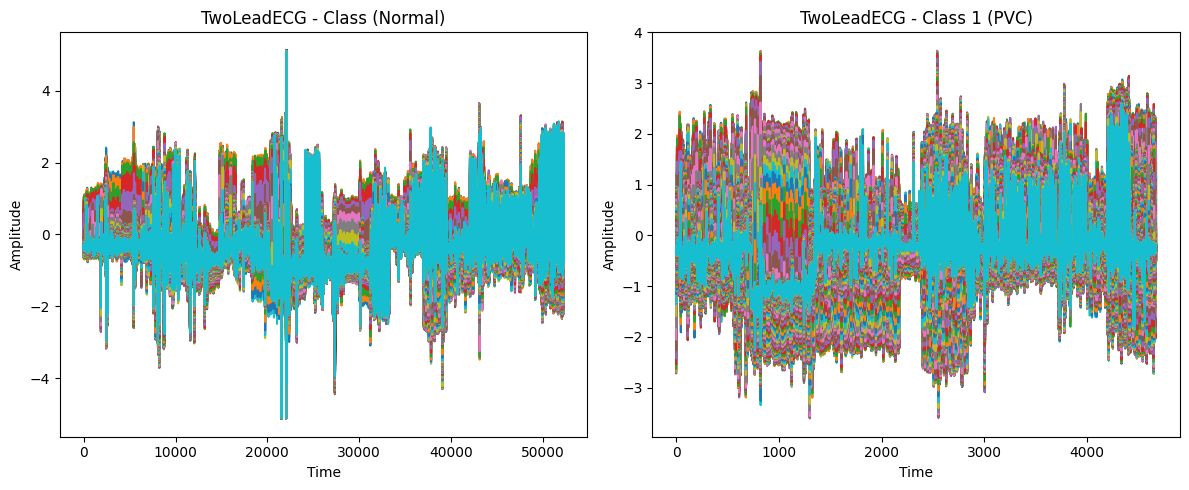

In [10]:
plot_two_signals(X,y)

5) Run SVM using PET as input data

In [ ]:
#############################################
# PET
#############################################

n_points = 400
layer = build_lowerstar_layer(n_points)

X_pet, y_pet = build_dataset_from_ecg(records_id=106, layer, n_points=n_points)

X_train, X_test, y_train, y_test = train_test_split(
        X_pet, y_pet, test_size=0.3, random_state=0, stratify=y
    )

results_pet, cm_pet = experiment_ecg(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name="PET",
)

#############################################
# RAW SIGNAL
#############################################


X_raw, y_raw = load_mitbih_beats(record_id=106)

X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.3, random_state=0, stratify=y
    )


results_raw, cm_raw = experiment_ecg(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name="RAW",
)


=== PET ===

1-NN Euclidean
Accuracy           : 0.9885
Balanced accuracy  : 0.9860
Macro F1           : 0.9850
Confusion matrix:
[[449   4]
 [  3 153]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       453
           1       0.97      0.98      0.98       156

    accuracy                           0.99       609
   macro avg       0.98      0.99      0.98       609
weighted avg       0.99      0.99      0.99       609


Linear SVM
Accuracy           : 0.9918
Balanced accuracy  : 0.9903
Macro F1           : 0.9893
Confusion matrix:
[[450   3]
 [  2 154]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       453
           1       0.98      0.99      0.98       156

    accuracy                           0.99       609
   macro avg       0.99      0.99      0.99       609
weighted avg       0.99      0.99      0.99       609


RBF SV

En total

In [ ]:
# varias muestras
# records = [
#     "100","101","102","103","104","105","106","107","108","109",
#     "111","112","113","114","115","116","117","118","119","121",
#     "122","123","124","200","201","202","203","205","207","208",
#     "209","210","212","213","214"
# ]

# X, y = load_mitbih_all(records_id=records)

# print(X.shape)
# print(y.shape)

# unique, counts = np.unique(y, return_counts=True)

# print(dict(zip(unique, counts)))

#############################################
# PET
#############################################

n_points = 400
layer = build_lowerstar_layer(n_points)

X_pet, y_pet = build_dataset_from_ecg(records, layer, n_points=n_points)

X_pet, y_pet = balance_dataset(X_pet,y_pet)

print(X_pet.shape)
print(y_pet.shape)

unique, counts = np.unique(y_pet, return_counts=True)

print(dict(zip(unique, counts)))

X_train, X_test, y_train, y_test = train_test_split(
        X_pet, y_pet, test_size=0.3, random_state=0, stratify=y
    )

results_pet, cm_pet = experiment_ecg(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name="PET",
)

#############################################
# RAW SIGNAL
#############################################


X_raw, y_raw = load_mitbih_all(records_id=records)

X_raw, y_raw = balance_dataset(X_raw,y_raw)

print(X_raw.shape)
print(y_raw.shape)

unique, counts = np.unique(y_raw, return_counts=True)

print(dict(zip(unique, counts)))

X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.3, random_state=0, stratify=y
    )


results_raw, cm_raw = experiment_ecg(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name="RAW",
)



(56906, 400)
(56906,)
{np.int64(0): np.int64(52234), np.int64(1): np.int64(4672)}
